In [1]:
## import to train and test autoencoder for anamoly detection on normal dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
import os

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize']=(10,5) ## trying to set the default plot size

#reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
## now loading the preprocessed data
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')
X_train_normal = np.load('../data/processed/X_train_normal.npy')

print(f"X_train:        {X_train.shape}")
print(f"X_test:         {X_test.shape}")
print(f"X_train_normal: {X_train_normal.shape}")
n_features = X_train_normal.shape[1]
print(f"n_features:     {n_features}")


X_train:        (125973, 122)
X_test:         (22251, 122)
X_train_normal: (67343, 122)
n_features:     122


In [3]:
## definfing the model architecture
autoencoder=keras.Sequential([
    layers.Input(shape=(n_features,)),
    # encoder — compresses 122 features down to a bottleneck
   ##Dense(64,activation='relu',name='add1'),
    Dense(32,activation='relu',name='layer1'),
    Dense(16,activation='relu',name='layer2'),
    Dense(8,activation='relu',name='bottleneck'),
    # decoder — mirrors the encoder, reconstructs back to 122
    Dense(16,activation='relu',name='layer4'),
    Dense(32,activation='relu',name='layer5'),
   ## Dense(64,activation='relu',name='add2'),
    Dense(n_features,activation='sigmoid',name='layer6')
])

autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 32)             │         3,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (Dense)                  │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer6 (Dense)                  │ (None, 122)            │         4,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,314 (36.38 KB)

 Trainable params: 9,314 (36.38 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = autoencoder.fit(
    X_train_normal, X_train_normal,   # input == target — this is what makes it an autoencoder
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

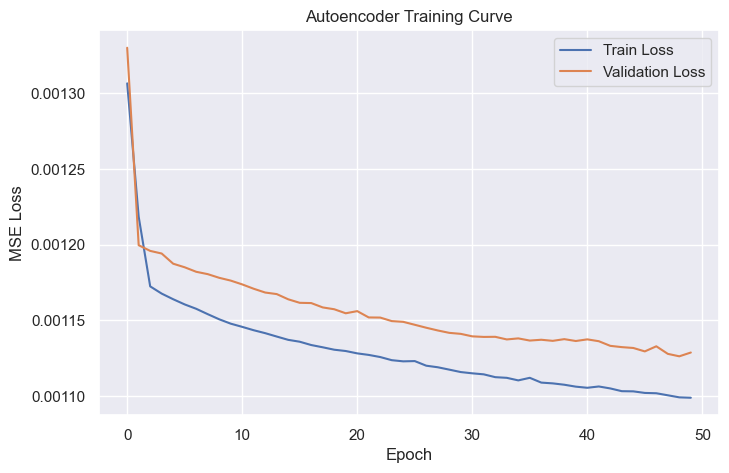

In [10]:
## ploting the figure to see the how mse loss and val_loss decreases
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Curve')
plt.legend()
plt.show()

In [11]:
## reconstruction error on normal training data — used to set threshold tau
reconstructions_normal = autoencoder.predict(X_train_normal, batch_size=256, verbose=0)

# per-sample MSE: mean squared error across all 122 features, for each row
recon_error_normal = np.mean(np.square(X_train_normal - reconstructions_normal), axis=1)

print(f"recon_error_normal shape: {recon_error_normal.shape}")
print(f"min:    {recon_error_normal.min():.6f}")
print(f"mean:   {recon_error_normal.mean():.6f}")
print(f"median: {np.median(recon_error_normal):.6f}")
print(f"max:    {recon_error_normal.max():.6f}")

recon_error_normal shape: (67343,)
min:    0.000000
mean:   0.001110
median: 0.000035
max:    0.052163


this is a good sign cause our autoencoder must produce less reconstruction error for normal data only 

That distribution tells us something important: median (0.000048) is ~40x smaller than the mean (0.001871), with a long right tail up to 0.082. This is classic heavy right-skew — most normal traffic reconstructs almost perfectly, but a minority of "harder" normal samples pull the mean up.

Threshold (tau) at 97th percentile: 0.008736
% of normal train samples above tau: 3.00%


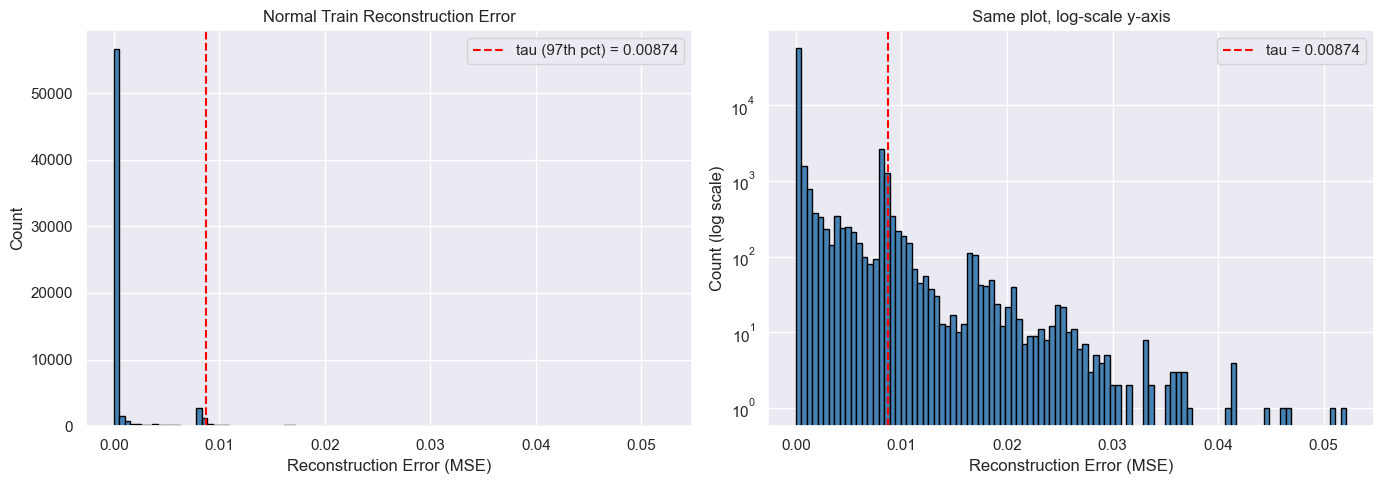

In [12]:
## setting threshold tau using percentile of normal reconstruction error
percentile = 97  # tune this — 95/97/99 are common starting points
tau = np.percentile(recon_error_normal, percentile)
print(f"Threshold (tau) at {percentile}th percentile: {tau:.6f}")

# how many normal samples would be (falsely) flagged at this tau?
false_flag_rate = np.mean(recon_error_normal > tau) * 100
print(f"% of normal train samples above tau: {false_flag_rate:.2f}%")

## visualizing the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(recon_error_normal, bins=100, color='steelblue', edgecolor='black')
axes[0].axvline(tau, color='red', linestyle='--', label=f'tau ({percentile}th pct) = {tau:.5f}')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Count')
axes[0].set_title('Normal Train Reconstruction Error')
axes[0].legend()

axes[1].hist(recon_error_normal, bins=100, color='steelblue', edgecolor='black')
axes[1].axvline(tau, color='red', linestyle='--', label=f'tau = {tau:.5f}')
axes[1].set_yscale('log')
axes[1].set_xlabel('Reconstruction Error (MSE)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Same plot, log-scale y-axis')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
## DIAGNOSTIC CELL — standalone anomaly-detection quality of the autoencoder
## (not part of the official notebook 03 roadmap — just for comparing 
## architectures before committing to the hybrid pipeline)

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# 1. Reconstruction error on X_train_normal → used to set τ
recon_train_normal = autoencoder.predict(X_train_normal, verbose=0)
error_train_normal = np.mean(np.square(X_train_normal - recon_train_normal), axis=1)

tau = np.percentile(error_train_normal, 85)  # try 97, 99 too — see how F1 shifts
print(f"Threshold (95th percentile of normal training error): {tau:.6f}")

# 2. Reconstruction error on X_test (has both normal + attack traffic)
recon_test = autoencoder.predict(X_test, verbose=0)
error_test = np.mean(np.square(X_test - recon_test), axis=1)

# 3. Collapse y_test to binary: 0 = normal, 1 = any attack
y_test_binary = (y_test != 0).astype(int)

# 4. Flag anomalies: error above τ → predicted attack (1)
y_pred_binary = (error_test > tau).astype(int)

# 5. Metrics
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix (rows=actual, cols=predicted):")
print("           Pred Normal  Pred Attack")
cm = confusion_matrix(y_test_binary, y_pred_binary)
print(f"Actual Normal   {cm[0][0]:>6}      {cm[0][1]:>6}")
print(f"Actual Attack   {cm[1][0]:>6}      {cm[1][1]:>6}")

Threshold (95th percentile of normal training error): 0.000690

Precision: 0.8917
Recall:    0.8880
F1 Score:  0.8898

Confusion Matrix (rows=actual, cols=predicted):
           Pred Normal  Pred Attack
Actual Normal     8358        1353
Actual Attack     1405       11135


In [14]:
## reconstruction error on FULL train and test sets (all 5 classes, not just normal)
recon_train_full = autoencoder.predict(X_train, batch_size=256, verbose=0)
recon_test_full  = autoencoder.predict(X_test, batch_size=256, verbose=0)

recon_error_train = np.mean(np.square(X_train - recon_train_full), axis=1)
recon_error_test  = np.mean(np.square(X_test - recon_test_full), axis=1)

print(f"recon_error_train shape: {recon_error_train.shape}")
print(f"recon_error_test shape:  {recon_error_test.shape}")

print(f"\nTrain — mean: {recon_error_train.mean():.6f}, median: {np.median(recon_error_train):.6f}")
print(f"Test  — mean: {recon_error_test.mean():.6f}, median: {np.median(recon_error_test):.6f}")

recon_error_train shape: (125973,)
recon_error_test shape:  (22251,)

Train — mean: 0.016078, median: 0.003702
Test  — mean: 0.014927, median: 0.008224


In [15]:
content_idx = np.load('../data/processed/content_idx.npy')
traffic_idx = np.load('../data/processed/traffic_idx.npy')
basic_idx   = np.load('../data/processed/basic_idx.npy')
non_content_idx = np.concatenate([traffic_idx, basic_idx])

recon_error_content_train = np.mean(np.square(
    (X_train - recon_train_full)[:, content_idx]), axis=1)
recon_error_content_test = np.mean(np.square(
    (X_test - recon_test_full)[:, content_idx]), axis=1)

recon_error_other_train = np.mean(np.square(
    (X_train - recon_train_full)[:, non_content_idx]), axis=1)
recon_error_other_test = np.mean(np.square(
    (X_test - recon_test_full)[:, non_content_idx]), axis=1)

print(f"Content error   — train mean: {recon_error_content_train.mean():.6f}, test mean: {recon_error_content_test.mean():.6f}")
print(f"Non-content err — train mean: {recon_error_other_train.mean():.6f}, test mean: {recon_error_other_test.mean():.6f}")

np.save('../data/processed/recon_error_content_train.npy', recon_error_content_train)
np.save('../data/processed/recon_error_content_test.npy', recon_error_content_test)
np.save('../data/processed/recon_error_other_train.npy', recon_error_other_train)
np.save('../data/processed/recon_error_other_test.npy', recon_error_other_test)

Content error   — train mean: 0.000409, test mean: 0.002955
Non-content err — train mean: 0.017946, test mean: 0.016355


In [16]:
## checking label format before plotting by class
print("y_train dtype:", y_train.dtype)
print("y_train unique values:", np.unique(y_train))
print("y_test unique values:", np.unique(y_test))

y_train dtype: int64
y_train unique values: [0 1 2 3 4]
y_test unique values: [0 1 2 3 4]


--- TRAIN ---
Normal   (n= 67343): mean=0.001110, median=0.000035
DoS      (n= 45927): mean=0.036027, median=0.035450
Probe    (n= 11656): mean=0.025070, median=0.021323
R2L      (n=   995): mean=0.003359, median=0.000474
U2R      (n=    52): mean=0.007987, median=0.008619

--- TEST ---
Normal   (n=  9711): mean=0.001682, median=0.000027
DoS      (n=  7167): mean=0.028852, median=0.031162
Probe    (n=  2421): mean=0.034752, median=0.038421
R2L      (n=  2885): mean=0.008435, median=0.001943
U2R      (n=    67): mean=0.008490, median=0.008347



/var/folders/07/zkvtwz216_q7kwpfdzr_bj6m0000gn/T/ipykernel_92211/2098975225.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(label_map.values()), showfliers=False)
/var/folders/07/zkvtwz216_q7kwpfdzr_bj6m0000gn/T/ipykernel_92211/2098975225.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(label_map.values()), showfliers=False)


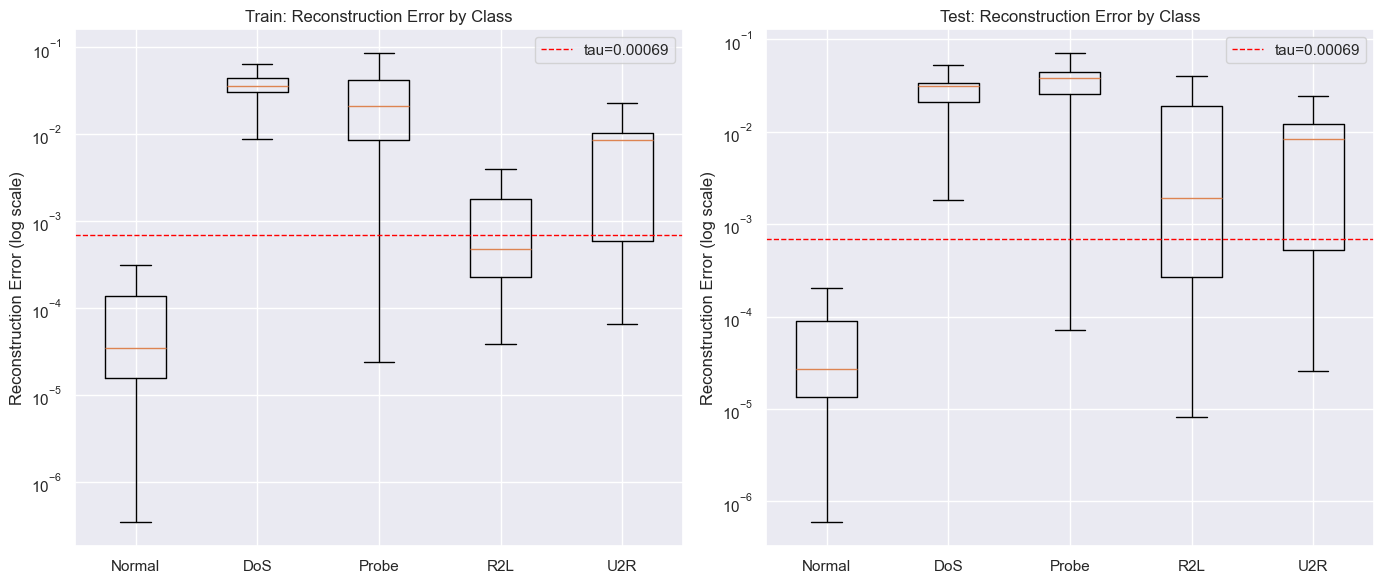

In [17]:
## reconstruction error by class — using confirmed mapping from notebook 02
label_map = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}

def error_summary_by_class(recon_error, y, dataset_name):
    print(f"--- {dataset_name} ---")
    for class_id, class_name in label_map.items():
        mask = (y == class_id)
        errs = recon_error[mask]
        print(f"{class_name:8s} (n={mask.sum():6d}): mean={errs.mean():.6f}, median={np.median(errs):.6f}")
    print()

error_summary_by_class(recon_error_train, y_train, "TRAIN")
error_summary_by_class(recon_error_test, y_test, "TEST")

## boxplot — reconstruction error distribution per class, log scale to handle skew
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, recon_error, y, title in [
    (axes[0], recon_error_train, y_train, "Train"),
    (axes[1], recon_error_test, y_test, "Test")
]:
    data = [recon_error[y == cid] for cid in label_map]
    ax.boxplot(data, labels=list(label_map.values()), showfliers=False)
    ax.set_yscale('log')
    ax.set_ylabel('Reconstruction Error (log scale)')
    ax.set_title(f'{title}: Reconstruction Error by Class')
    ax.axhline(tau, color='red', linestyle='--', linewidth=1, label=f'tau={tau:.5f}')
    ax.legend()

plt.tight_layout()
plt.show()

In [18]:
## saving all artifacts from notebook 03
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# 1. the trained autoencoder itself
autoencoder.save('../models/autoencoder.keras')

# 2. threshold tau — plain text, simple to read back later
with open('../models/threshold.txt', 'w') as f:
    f.write(str(tau))

# 3. reconstruction error arrays — these become feature 42 in notebook 04
np.save('../data/processed/recon_error_train.npy', recon_error_train)
np.save('../data/processed/recon_error_test.npy', recon_error_test)

print("Saved:")
print("  models/autoencoder.keras")
print(f"  models/threshold.txt (tau = {tau:.6f})")
print(f"  data/processed/recon_error_train.npy {recon_error_train.shape}")
print(f"  data/processed/recon_error_test.npy  {recon_error_test.shape}")

Saved:
  models/autoencoder.keras
  models/threshold.txt (tau = 0.000690)
  data/processed/recon_error_train.npy (125973,)
  data/processed/recon_error_test.npy  (22251,)
